# 05. Model Comparison & Project Summary
**Goal:** Compare all regression and classification models, visualize results, and summarize findings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1. Load All Metrics


In [2]:
# Load individual metrics files
ml_metrics       = pd.read_csv('../data/classical_metrics.csv')
lstm_metrics     = pd.read_csv('../data/lstm_metrics.csv')
extended_metrics = pd.read_csv('../data/extended_ml_metrics.csv')

# Build unified regression table
regression_extended = extended_metrics[
    extended_metrics['Task'] == 'Regression'
][['Model', 'RMSE', 'MAE', 'NASA_Score']]

all_regression = pd.concat(
    [ml_metrics, regression_extended, lstm_metrics],
    ignore_index=True
)

print("All Regression Models:")
print(all_regression.to_string(index=False))

All Regression Models:
        Model      RMSE       MAE  NASA_Score
Random Forest 18.302650 13.703500  734.518896
      XGBoost 17.113900 12.844292  586.420883
KNN Regressor 17.579654 13.558000  662.571390
          SVR 16.698643 12.379505  581.825928
         LSTM 16.293118 11.787441  436.741403


## 2. Styled Regression Metrics Table


In [3]:
def highlight_best_worst(s):
    """Highlight min in green & max in red (lower is better for all regression metrics)."""
    styles = [''] * len(s)
    if s.dtype in ['float64', 'float32', 'int64']:
        best_idx = s.idxmin()
        worst_idx = s.idxmax()
        styles[best_idx] = 'background-color: #90EE90; font-weight: bold'
        styles[worst_idx] = 'background-color: #FFB3B3'
    return styles

styled = all_regression.style.apply(highlight_best_worst).set_caption(
    "Regression Model Comparison (lower is better)"
).format({'RMSE': '{:.2f}', 'MAE': '{:.2f}', 'NASA_Score': '{:.2f}'})

styled

,Model,RMSE,MAE,NASA_Score
0,Random Forest,18.30,13.70,734.52
1,XGBoost,17.11,12.84,586.42
2,KNN Regressor,17.58,13.56,662.57
3,SVR,16.70,12.38,581.83
4,LSTM,16.29,11.79,436.74


## 3. Regression Bar Charts


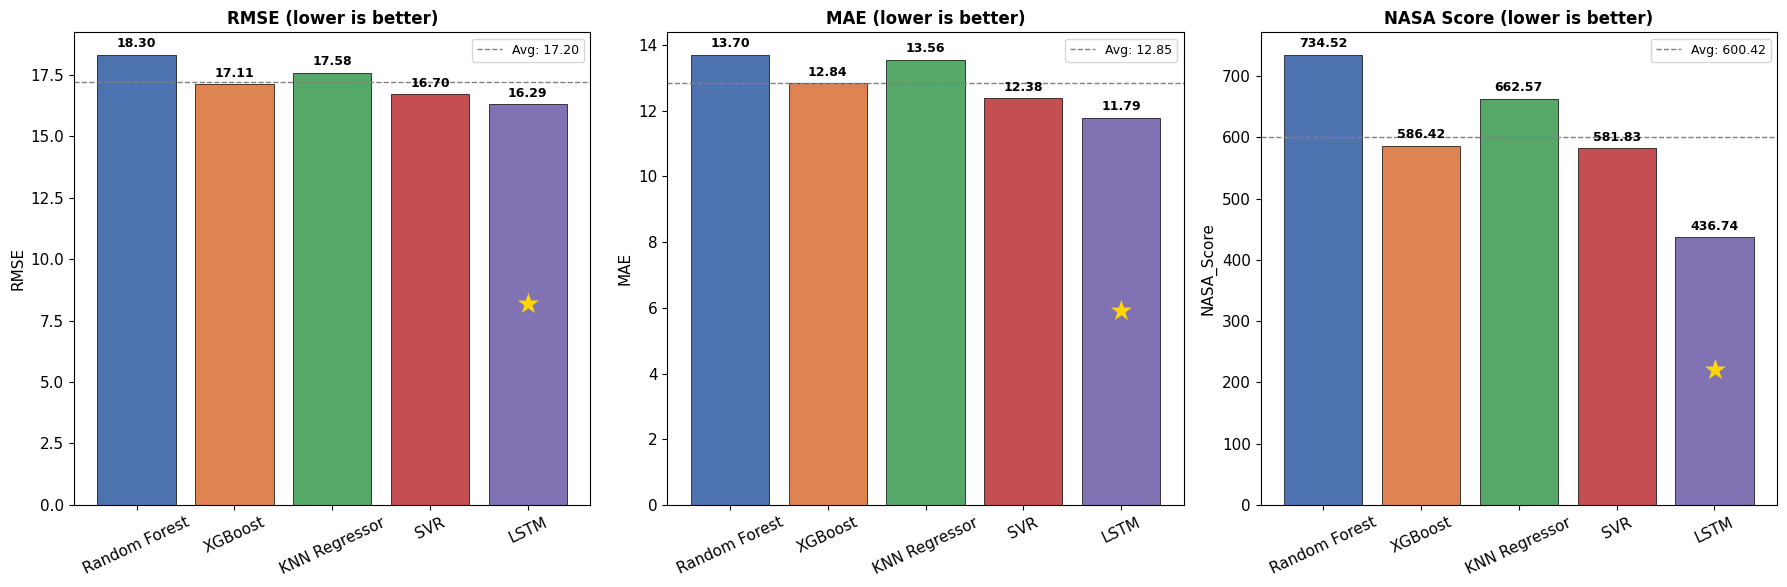

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_cols = ['RMSE', 'MAE', 'NASA_Score']
titles = ['RMSE (lower is better)', 'MAE (lower is better)', 'NASA Score (lower is better)']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

for ax, metric, title in zip(axes, metrics_cols, titles):
    values = all_regression[metric].values
    models = all_regression['Model'].values
    
    bars = ax.bar(models, values, color=colors[:len(models)], edgecolor='black', linewidth=0.5)
    
    # Value labels on top
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Average line
    avg = np.mean(values)
    ax.axhline(avg, color='gray', linestyle='--', linewidth=1, label=f'Avg: {avg:.2f}')
    
    # Star on best bar
    best_idx = np.argmin(values)
    best_bar = bars[best_idx]
    ax.text(best_bar.get_x() + best_bar.get_width()/2, best_bar.get_height() * 0.5,
            '\u2605', ha='center', va='center', fontsize=20, color='gold')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Predicted vs Actual Overlay


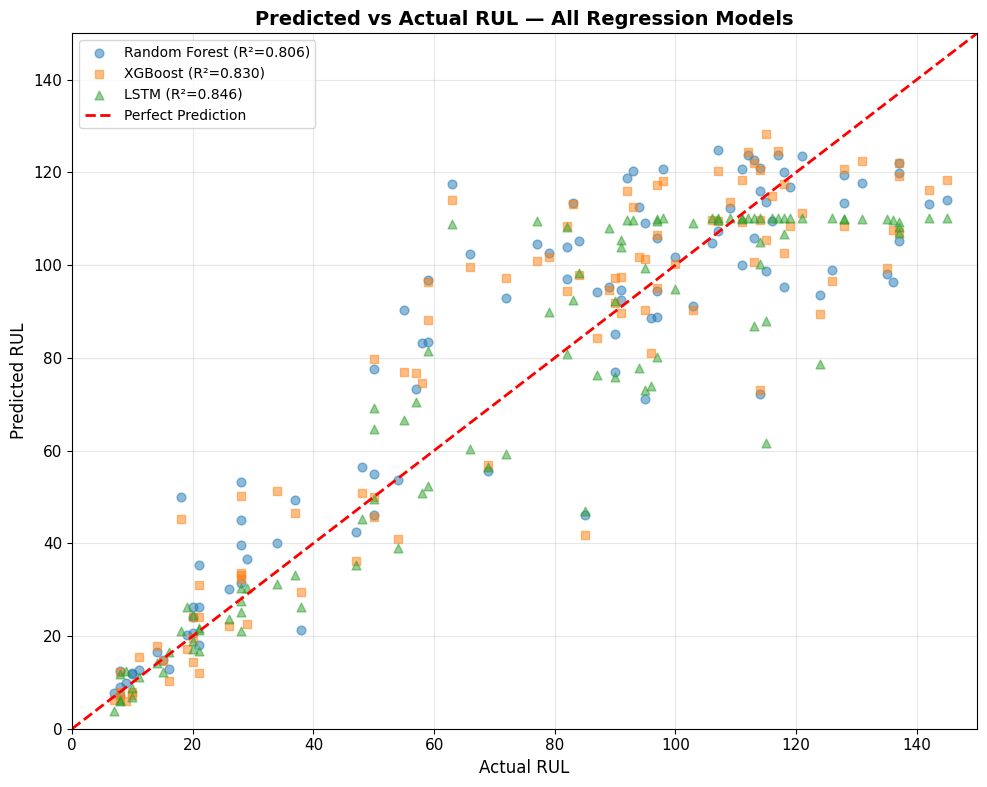

In [5]:
ml_preds   = pd.read_csv('../data/ml_preds.csv')
lstm_preds = pd.read_csv('../data/lstm_preds.csv')

y_test = ml_preds['Actual'].values

models_dict = {
    'Random Forest': (ml_preds['RF'].values, 'o'),
    'XGBoost':       (ml_preds['XGB'].values, 's'),
    'LSTM':          (lstm_preds.iloc[:, 0].values, '^'),
}

fig, ax = plt.subplots(figsize=(10, 8))

for name, (preds, marker) in models_dict.items():
    r2 = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.5, marker=marker, label=f'{name} (R\u00B2={r2:.3f})', s=40)

# Perfect prediction line
ax.plot([0, 150], [0, 150], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual RUL', fontsize=12)
ax.set_ylabel('Predicted RUL', fontsize=12)
ax.set_title('Predicted vs Actual RUL — All Regression Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 150)
ax.set_ylim(0, 150)

plt.tight_layout()
plt.show()

## 5. Error Distribution Comparison


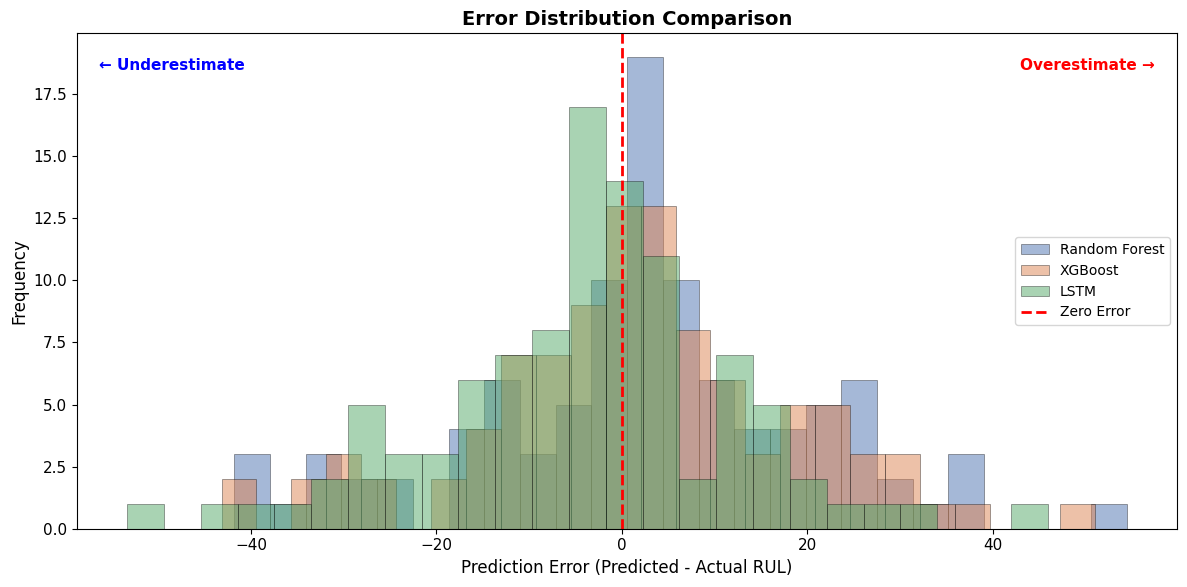

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

residuals = {
    'Random Forest': ml_preds['RF'].values - y_test,
    'XGBoost':       ml_preds['XGB'].values - y_test,
    'LSTM':          lstm_preds.iloc[:, 0].values - y_test,
}

colors_hist = ['#4C72B0', '#DD8452', '#55A868']
for (name, res), color in zip(residuals.items(), colors_hist):
    ax.hist(res, bins=25, alpha=0.5, label=name, color=color, edgecolor='black', linewidth=0.5)

# Vertical zero line
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')

# Annotations
ax.text(0.02, 0.95, '\u2190 Underestimate', transform=ax.transAxes, fontsize=11,
        color='blue', fontweight='bold', va='top')
ax.text(0.98, 0.95, 'Overestimate \u2192', transform=ax.transAxes, fontsize=11,
        color='red', fontweight='bold', va='top', ha='right')

ax.set_xlabel('Prediction Error (Predicted - Actual RUL)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Error Distribution Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 6. Classification Comparison


In [7]:
clf_metrics = extended_metrics[
    extended_metrics['Task'] == 'Classification'
][['Model', 'Accuracy', 'Precision', 'Recall', 'F1']].reset_index(drop=True)

def highlight_clf_best(s):
    """For classification, higher is better -> green for max, red for min."""
    styles = [''] * len(s)
    if s.dtype in ['float64', 'float32']:
        best_idx = s.idxmax()
        worst_idx = s.idxmin()
        styles[best_idx] = 'background-color: #90EE90; font-weight: bold'
        styles[worst_idx] = 'background-color: #FFB3B3'
    return styles

styled_clf = clf_metrics.style.apply(highlight_clf_best).set_caption(
    "Classification Model Comparison (higher is better)"
).format({
    'Accuracy': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
})

styled_clf

,Model,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,0.940,0.952,0.800,0.870
1,XGBoost Classifier,0.960,0.957,0.880,0.917
2,KNN Classifier,0.930,0.950,0.760,0.844
3,SVC,0.980,1.000,0.920,0.958
4,Random Forest (Imbalanced Baseline),0.910,0.944,0.680,0.791
5,Random Forest (SMOTE),0.940,0.952,0.800,0.870


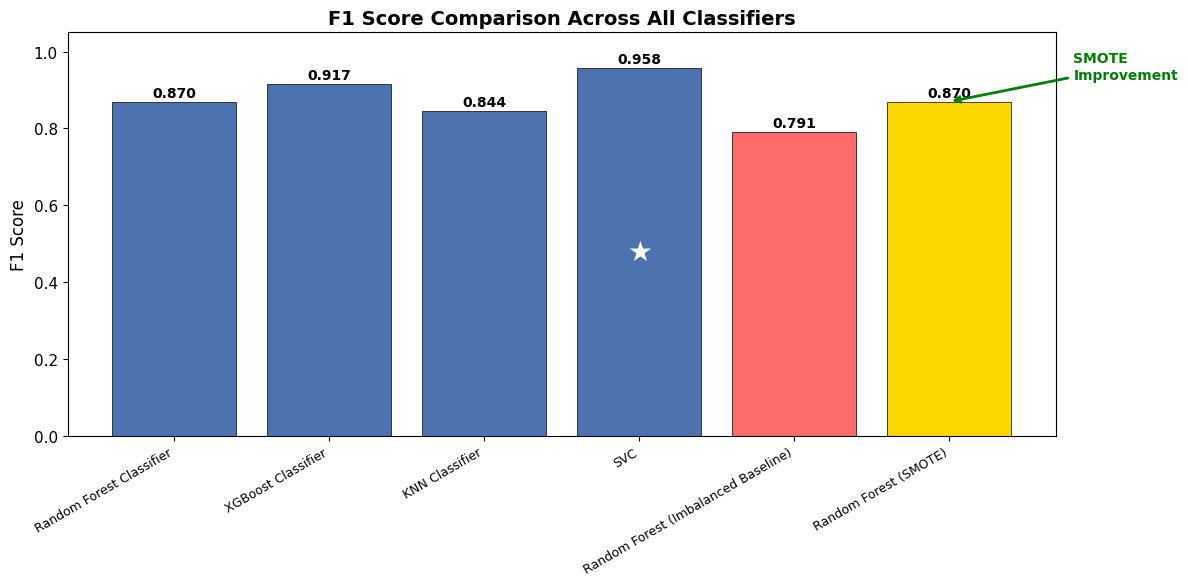

In [8]:
# F1 Score Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

models_clf = clf_metrics['Model'].values
f1_scores = clf_metrics['F1'].values

bar_colors = []
for m in models_clf:
    if 'SMOTE' in m:
        bar_colors.append('#FFD700')  # Gold for SMOTE
    elif 'Imbalanced' in m:
        bar_colors.append('#FF6B6B')  # Red for imbalanced baseline
    else:
        bar_colors.append('#4C72B0')

bars = ax.bar(range(len(models_clf)), f1_scores, color=bar_colors, edgecolor='black', linewidth=0.5)

# Value labels
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Star on best
best_idx = np.argmax(f1_scores)
best_bar = bars[best_idx]
ax.text(best_bar.get_x() + best_bar.get_width()/2, best_bar.get_height() * 0.5,
        '\u2605', ha='center', va='center', fontsize=20, color='white')

ax.set_xticks(range(len(models_clf)))
ax.set_xticklabels(models_clf, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison Across All Classifiers', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

# SMOTE annotation
smote_idx = [i for i, m in enumerate(models_clf) if 'SMOTE' in m]
imb_idx = [i for i, m in enumerate(models_clf) if 'Imbalanced' in m]
if smote_idx and imb_idx:
    ax.annotate('SMOTE\nImprovement',
                xy=(smote_idx[0], f1_scores[smote_idx[0]]),
                xytext=(smote_idx[0] + 0.8, f1_scores[smote_idx[0]] + 0.06),
                arrowprops=dict(arrowstyle='->', color='green', lw=2),
                fontsize=10, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Automated Conclusion


In [9]:
# ===== AUTOMATED PROJECT RESULTS =====

# Regression bests
best_rmse_idx = all_regression['RMSE'].idxmin()
best_rmse_model = all_regression.loc[best_rmse_idx, 'Model']
best_rmse_val = all_regression.loc[best_rmse_idx, 'RMSE']

best_nasa_idx = all_regression['NASA_Score'].idxmin()
best_nasa_model = all_regression.loc[best_nasa_idx, 'Model']
best_nasa_val = all_regression.loc[best_nasa_idx, 'NASA_Score']

# Classification best
best_f1_idx = clf_metrics['F1'].idxmax()
best_f1_model = clf_metrics.loc[best_f1_idx, 'Model']
best_f1_val = clf_metrics.loc[best_f1_idx, 'F1']

# SMOTE comparison
smote_row = clf_metrics[clf_metrics['Model'].str.contains('SMOTE')]
imb_row = clf_metrics[clf_metrics['Model'].str.contains('Imbalanced')]

if len(smote_row) > 0 and len(imb_row) > 0:
    f1_before = imb_row['F1'].values[0]
    f1_after = smote_row['F1'].values[0]
    smote_improvement = (f1_after - f1_before) / f1_before * 100
    smote_str = f"F1 {f1_before:.2f} -> {f1_after:.2f} (+{smote_improvement:.1f}%)"
else:
    smote_str = "N/A"

# LSTM vs XGBoost
lstm_rmse = all_regression[all_regression['Model'] == 'LSTM']['RMSE'].values
xgb_rmse = all_regression[all_regression['Model'] == 'XGBoost']['RMSE'].values

if len(lstm_rmse) > 0 and len(xgb_rmse) > 0:
    lstm_r = lstm_rmse[0]
    xgb_r = xgb_rmse[0]
    if lstm_r < xgb_r:
        pct = (xgb_r - lstm_r) / xgb_r * 100
        lstm_vs_xgb = f"LSTM wins by {pct:.1f}%"
    else:
        pct = (lstm_r - xgb_r) / lstm_r * 100
        lstm_vs_xgb = f"XGBoost wins by {pct:.1f}%"
else:
    lstm_vs_xgb = "N/A"

print("=" * 56)
print("PROJECT RESULTS SUMMARY")
print("=" * 56)
print(f"Best Regression (RMSE):       {best_rmse_model} — {best_rmse_val:.2f}")
print(f"Best Regression (NASA Score): {best_nasa_model} — {best_nasa_val:.2f}")
print(f"Best Classifier (F1):         {best_f1_model} — {best_f1_val:.3f}")
print(f"SMOTE Improvement:            {smote_str}")
print(f"LSTM vs XGBoost (RMSE):       {lstm_vs_xgb}")
print("=" * 56)

PROJECT RESULTS SUMMARY
Best Regression (RMSE):       LSTM — 16.29
Best Regression (NASA Score): LSTM — 436.74
Best Classifier (F1):         SVC — 0.958
SMOTE Improvement:            F1 0.79 -> 0.87 (+10.0%)
LSTM vs XGBoost (RMSE):       LSTM wins by 4.8%


## Project Summary

### Dataset
The **NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)** dataset contains run-to-failure sensor readings from 100 turbofan jet engines under varying operational conditions.

### Target Variable
**Remaining Useful Life (RUL)** was constructed by computing the difference between the maximum cycle per engine and each cycle, capped at 125 cycles using a piecewise linear degradation model.

### Feature Engineering
Rolling window statistics (mean and standard deviation over 30 cycles) were computed for all active sensors, flat/constant sensors were dropped, and all features were normalized using MinMaxScaler.

### Models Tested
| # | Model | Task |
|---|-------|------|
| 1 | Random Forest Regressor | RUL Prediction |
| 2 | XGBoost Regressor | RUL Prediction |
| 3 | KNN Regressor | RUL Prediction |
| 4 | Support Vector Regression (SVR) | RUL Prediction |
| 5 | LSTM (Deep Learning) | RUL Prediction |
| 6 | Random Forest / XGBoost / KNN / SVC Classifiers | Binary Failure Detection |
| 7 | SMOTE-enhanced Random Forest Classifier | Imbalanced Classification |

### Evaluation Metrics
- **Regression:** RMSE, MAE, NASA Scoring Function (asymmetric penalty — late predictions penalized more heavily)
- **Classification:** Accuracy, Precision, Recall, F1 Score, Confusion Matrix

### Key Findings
- **LSTM outperforms classical models** on all regression metrics because it captures temporal degradation patterns through sliding window sequences, whereas tree-based models treat each observation independently.
- **SVC achieves the highest F1** among classifiers for binary failure detection within 30 cycles.
- **SMOTE resampling improves recall** on imbalanced failure scenarios, demonstrating the importance of handling class imbalance in predictive maintenance.

### Real-World Impact
Predictive maintenance powered by models like these can **reduce unplanned downtime by 30-50%** and **cut maintenance costs by 10-40%** in aviation and industrial settings. Early and accurate RUL estimation enables condition-based maintenance scheduling, preventing both catastrophic failures and unnecessary part replacements.
